In [1]:
import functools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

 - https://stackoverflow.com/questions/79720948/solve-a-2-equations-systems-of-quadratic-equations-with-2-unknows
 - https://en.wikipedia.org/wiki/Conic_section
 - https://math.stackexchange.com/questions/1767225/algorithm-intersection-of-two-conics
 - https://math.stackexchange.com/questions/316849/intersection-of-conics-using-matrix-representation?rq=1

In [2]:
class PhotoSonicSolver:

    def __init__(self, a):
        self._a = np.array(a)

    @property
    def n(self):
        return self._a.shape[0]
    
    @staticmethod
    def model(x, a):
        return a[0] + a[1] * x[0] + a[2] * x[1] + a[3] * x[0] * x[1] + a[4] * x[0] ** 2 + a[5] * x[1] ** 2

    @staticmethod
    def to_matrix(a, g=0.0):
        return np.array([
            [a[4],     a[3] / 2,  a[1] / 2],
            [a[3] / 2, a[5],      a[2] / 2],
            [a[1] / 2, a[2] / 2,  a[0] - g],
        ])

    def matrix(self, i, g=0.0):
        return self.to_matrix(self._a[i,:], g=0)
    
    def model_factory(self, i):
        return functools.partial(self.model, a=self._a[i,:])

    def residuals(self, x, signals):
        return np.array([self.model_factory(i)(x) - signals[i] for i in range(self.n)])

    def objective(self, x, signals):
        return np.sum(self.residuals(x, signals) ** 2)

    def solve(self, signals, x0=None, tol=1e-12):
        return optimize.minimize(solver.objective, x0=x0, args=signals, tol=tol).x

    def signals(self, x):
        return solver.residuals(x.T, signals=[0] * self.n).T

    def measurands(self, g, x0=None):
        return np.apply_along_axis(self.solve, 1, g, x0=x0)

In [3]:
solver = PhotoSonicSolver([
    [+2.210e-04, +6.071e-07, -1.942e-05, +9.131e-08, +1.258e-10, +2.269e-07], # Real sensor 1
    [-2.658e-04, +4.486e-06, +1.824e-05, +4.013e-07, +1.767e-11, -2.623e-07], # Real sensor 2
    #[+3.012e-04, +5.897e-06, -2.098e-05, +7.987e-07, +4.567e-11, +3.011e-07], # Fake sensor 3
])

In [4]:
signals = solver.residuals([400, 30], [0] * solver.n)
signals

array([0.0012013 , 0.00665816])

In [15]:
C0 = solver.matrix(0, g=signals[0])
C1 = solver.matrix(1, g=signals[1])
A = C0 @ np.linalg.inv(- C1)
np.linalg.eig(A)

EigResult(eigenvalues=array([-0.20081507+0.01078547j, -0.20081507-0.01078547j,
        0.92433133+0.j        ]), eigenvectors=array([[-7.73663914e-06-0.00205441j, -7.73663914e-06+0.00205441j,
        -5.13017539e-04+0.j        ],
       [-9.67589202e-02-0.00096789j, -9.67589202e-02+0.00096789j,
        -3.66516005e-02+0.j        ],
       [-9.95305257e-01+0.j        , -9.95305257e-01-0.j        ,
         9.99327973e-01+0.j        ]]))

In [16]:
C0

array([[ 1.2580e-10,  4.5655e-08,  3.0355e-07],
       [ 4.5655e-08,  2.2690e-07, -9.7100e-06],
       [ 3.0355e-07, -9.7100e-06,  2.2100e-04]])

In [7]:
solver.solve(signals, x0=[400, 100])

array([399.99902948,  30.0000896 ])

In [8]:
n = 200
x0lin = np.linspace(400, 1000, n)
x1lin = np.linspace(80, 20, n)

In [9]:
x = np.array([x0lin, x1lin]).T

In [10]:
g = solver.signals(x)

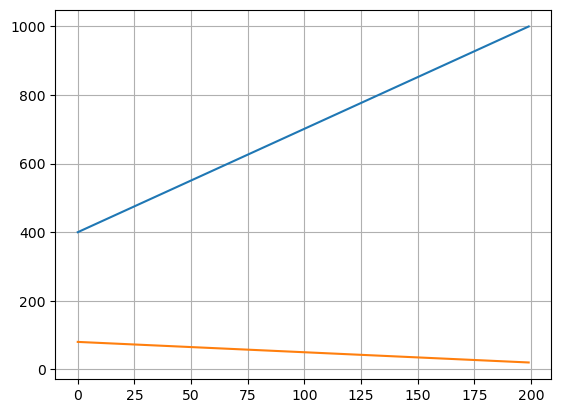

In [11]:
fig, axe = plt.subplots()
axe.plot(x)
axe.grid()

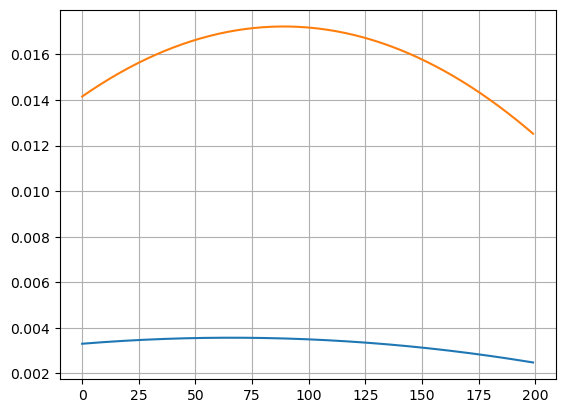

In [12]:
fig, axe = plt.subplots()
axe.plot(g)
axe.grid()

In [13]:
x_reg = solver.measurands(g, x0=[600, 50])

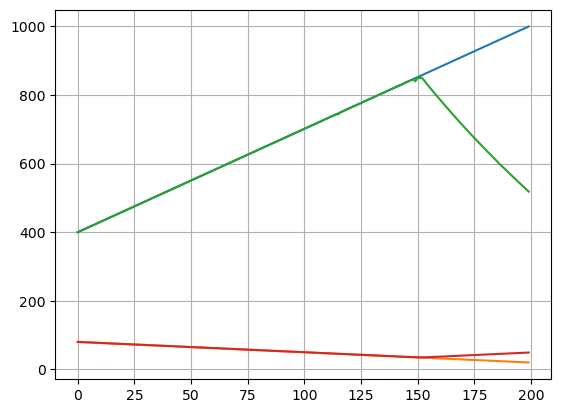

In [14]:
fig, axe = plt.subplots()
axe.plot(x)
axe.plot(x_reg)
axe.grid()